In [17]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from glob import glob
import pandas as pd
import shutil

In [ ]:
# #################################
# #### Size Variation Detection ###
# #################################

# def detect_crater_size(image_path, visualize=False):
#     """
#     Detect craters in an image and classify them by size.
    
#     Args:
#         image_path: Path to the image file
#         visualize: Whether to show visualization of detected contours
    
#     Returns:
#         size_category: Size category of the largest crater ('small', 'medium', 'large', 'massive')
#         area: Area of the largest crater in pixels
#     """
#     # Read the image
#     img = cv2.imread(image_path)
#     if img is None:
#         print(f"Error: Could not read image {image_path}")
#         return None, 0
    
#     # Convert to grayscale
#     gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
#     # Apply Gaussian blur to reduce noise
#     blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    
#     # Apply Canny edge detection
#     edges = cv2.Canny(blurred, 50, 150)
    
#     # Dilate the edges to close small gaps
#     kernel = np.ones((3, 3), np.uint8)
#     dilated = cv2.dilate(edges, kernel, iterations=1)
    
#     # Find contours
#     contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
#     # If no contours found, return None
#     if not contours:
#         return "unknown", 0
    
#     # Find the largest contour (assumed to be the main crater)
#     largest_contour = max(contours, key=cv2.contourArea)
#     area = cv2.contourArea(largest_contour)
    
#     # Visualize if requested
#     if visualize:
#         img_copy = img.copy()
#         cv2.drawContours(img_copy, [largest_contour], -1, (0, 255, 0), 2)
#         plt.figure(figsize=(10, 8))
#         plt.imshow(cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB))
#         plt.title(f"Area: {area:.2f} pixels")
#         plt.show()
    
#     return area

# def classify_craters_by_size(image_folder, output_csv='crater_sizes.csv', visualize_samples=False):
#     """
#     Process all images in a folder and classify craters by size.
    
#     Args:
#         image_folder: Folder containing crater images
#         output_csv: Path to save results
#         visualize_samples: Whether to visualize a few sample detections
#     """
#     # Get all image files
#     image_files = glob(os.path.join(image_folder, "*.jpg")) + \
#                   glob(os.path.join(image_folder, "*.png"))
    
#     results = []
    
#     # Process each image
#     for i, img_path in enumerate(image_files):
#         filename = os.path.basename(img_path)
        
#         # Show progress
#         if i % 10 == 0:
#             print(f"Processing image {i+1}/{len(image_files)}: {filename}")
        
#         # Visualize a few samples
#         should_visualize = visualize_samples and i < 5
        
#         # Detect crater size
#         area = detect_crater_size(img_path, visualize=should_visualize)
        
#         # Store results
#         results.append({
#             'filename': filename,
#             'area': area,
#         })
    
#     # Convert to DataFrame
#     df = pd.DataFrame(results)
    
#     # Define size categories based on area percentiles
#     if not df.empty and df['area'].sum() > 0:
#         df['size_category'] = pd.qcut(
#             df['area'], 
#             q=4, 
#             labels=['small', 'medium', 'large', 'massive']
#         )
#     else:
#         print("Warning: No valid crater areas detected")
#         df['size_category'] = 'unknown'
    
#     # Save results
#     df.to_csv(output_csv, index=False)
    
#     # Print summary
#     print("\nSize distribution:")
#     print(df['size_category'].value_counts())
    
#     return df

In [19]:
#################################
#### Light Variation Detection ###
#################################

def analyze_light_hsv(image_path, visualize=False):
    """
    Analyze light characteristics using HSV color space.
    
    Args:
        image_path: Path to the image file
        visualize: Whether to show visualization
        
    Returns:
        h_mean: Mean hue
        s_mean: Mean saturation
        v_mean: Mean value (brightness)
        s_std: Standard deviation of saturation
        v_std: Standard deviation of value
    """
    # Read the image
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not read image {image_path}")
        return None, None, None, None, None
    
    # Convert to HSV
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    
    # Split channels
    h, s, v = cv2.split(hsv)
    
    # Calculate statistics
    h_mean = np.mean(h)  # Average hue
    s_mean = np.mean(s)  # Average saturation
    v_mean = np.mean(v)  # Average brightness (value)
    
    h_std = np.std(h)    # Hue variation
    s_std = np.std(s)    # Saturation variation
    v_std = np.std(v)    # Brightness variation
    
    # Visualize if requested
    if visualize:
        plt.figure(figsize=(15, 8))
        
        # Plot the image
        plt.subplot(2, 3, 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title("Original Image")
        plt.axis('off')
        
        # Plot HSV channels
        plt.subplot(2, 3, 2)
        plt.imshow(h, cmap='hsv')
        plt.title(f"Hue (Mean: {h_mean:.1f}, StdDev: {h_std:.1f})")
        plt.axis('off')
        
        plt.subplot(2, 3, 3)
        plt.imshow(s, cmap='gray')
        plt.title(f"Saturation (Mean: {s_mean:.1f}, StdDev: {s_std:.1f})")
        plt.axis('off')
        
        plt.subplot(2, 3, 4)
        plt.imshow(v, cmap='gray')
        plt.title(f"Value (Mean: {v_mean:.1f}, StdDev: {v_std:.1f})")
        plt.axis('off')
        
        # Plot histograms
        plt.subplot(2, 3, 5)
        plt.hist(s.ravel(), 256, [0, 256])
        plt.title("Saturation Histogram")
        
        plt.subplot(2, 3, 6)
        plt.hist(v.ravel(), 256, [0, 256])
        plt.title("Value Histogram")
        
        plt.tight_layout()
        plt.show()
    
    return h_mean, s_mean, v_mean, s_std, v_std

def classify_images_by_hsv(image_folder, output_csv='hsv_analysis.csv', visualize_samples=False):
    """
    Process all images in a folder and classify them by HSV characteristics.
    """
    # Get all image files
    image_files = glob(os.path.join(image_folder, "*.jpg")) + \
                  glob(os.path.join(image_folder, "*.png"))
    
    results = []
    
    # Process each image
    for i, img_path in enumerate(image_files):
        filename = os.path.basename(img_path)
        
        # Show progress
        if i % 10 == 0:
            print(f"Processing image {i+1}/{len(image_files)}: {filename}")
        
        # Visualize a few samples
        should_visualize = visualize_samples and i < 5
        
        # Analyze HSV
        h_mean, s_mean, v_mean, s_std, v_std = analyze_light_hsv(
            img_path, visualize=should_visualize
        )
        
        # Store results
        results.append({
            'filename': filename,
            'h_mean': h_mean,
            's_mean': s_mean,
            'v_mean': v_mean,
            's_std': s_std,
            'v_std': v_std
        })
    
    # Convert to DataFrame
    df = pd.DataFrame(results)
    
    # Use fixed thresholds as suggested by professor
    # These thresholds should be adjusted based on your dataset
    
    # Value (brightness) categories
    df['brightness'] = pd.cut(
        df['v_mean'], 
        bins=[0, 85, 170, 255],
        labels=['dark', 'medium', 'bright'],
        include_lowest=True
    )
    
    # Saturation categories
    df['saturation'] = pd.cut(
        df['s_mean'],
        bins=[0, 60, 120, 255],
        labels=['low_sat', 'medium_sat', 'high_sat'],
        include_lowest=True
    )
    
    # Contrast categories (based on value std)
    df['contrast'] = pd.cut(
        df['v_std'],
        bins=[0, 30, 60, 255],
        labels=['low_contrast', 'medium_contrast', 'high_contrast'],
        include_lowest=True
    )

    # Hue Categories
    df['hue_category'] = pd.cut(
        df['h_mean'],
        bins=[0, 10, 20, 30, 180],
        labels=['red', 'orange', 'yellow_brown', 'other'],
        include_lowest=True
    )
    
    # Save results
    df.to_csv(output_csv, index=False)
    
    # Print summary
    print("\nBrightness distribution:")
    print(df['brightness'].value_counts())
    print("\nSaturation distribution:")
    print(df['saturation'].value_counts())
    print("\nContrast distribution:")
    print(df['contrast'].value_counts())
    print("\nHue distribution:")
    print(df['hue_category'].value_counts())
    
    
    return df

In [20]:
########################
#### Helpers ###########
########################

def clean_folder(folder_path):
    """
    Remove all files from a folder while preserving the folder itself.
    
    Args:
        folder_path: Path to the folder to be cleaned
    
    Returns:
        int: Number of files removed
    """
    if not os.path.exists(folder_path):
        return 0
        
    count = 0
    for item in os.listdir(folder_path):
        item_path = os.path.join(folder_path, item)
        if os.path.isfile(item_path):
            try:
                os.remove(item_path)
                count += 1
            except Exception as e:
                print(f"Error removing {item_path}: {e}")
        elif os.path.isdir(item_path):
            # Skip subdirectories - only remove files
            pass
    
    return count

In [22]:
# #################################
# #### Classify By Size ###########
# #################################

# image_folder = "real_craters"
# df = classify_craters_by_size(image_folder, visualize_samples=True)

#  # Create subfolders for each size category
# for category in ['small', 'medium', 'large', 'massive']:
    
#     # Create category folder if it doesn't exist
#     category_path = os.path.join(image_folder, category)
#     os.makedirs(category_path, exist_ok=True)
    
#     # Clean the folder
#     removed_count = clean_folder(category_path)
#     print(f"Cleaned {category_path}: removed {removed_count} files")

# # Copy images to their respective size category folders
# for _, row in df.iterrows():
#     if row['size_category'] != 'unknown':
#         source = os.path.join(image_folder, row['filename'])
#         dest = os.path.join(image_folder, row['size_category'], row['filename'])
#         # Uncomment to actually copy files
#         shutil.copy2(source, dest)

Processing image 1/135: 011_png.rf.8ac312b4898f0106d10b76952a55d237.jpg


/var/folders/_0/y7fb2pw57s517sf8y5wzbdvh0000gn/T/ipykernel_42602/3086131260.py:69: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(s.ravel(), 256, [0, 256])
/var/folders/_0/y7fb2pw57s517sf8y5wzbdvh0000gn/T/ipykernel_42602/3086131260.py:73: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(v.ravel(), 256, [0, 256])


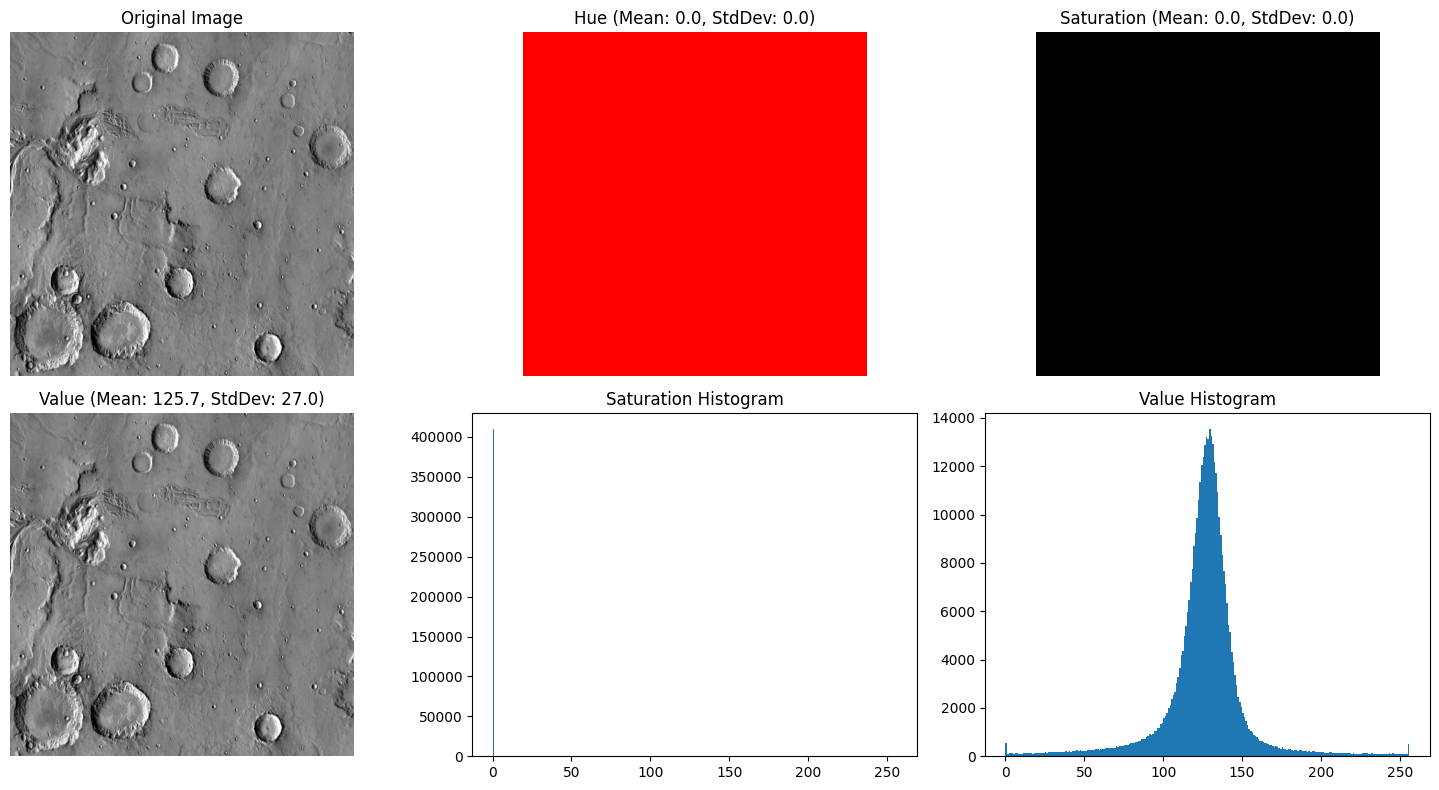

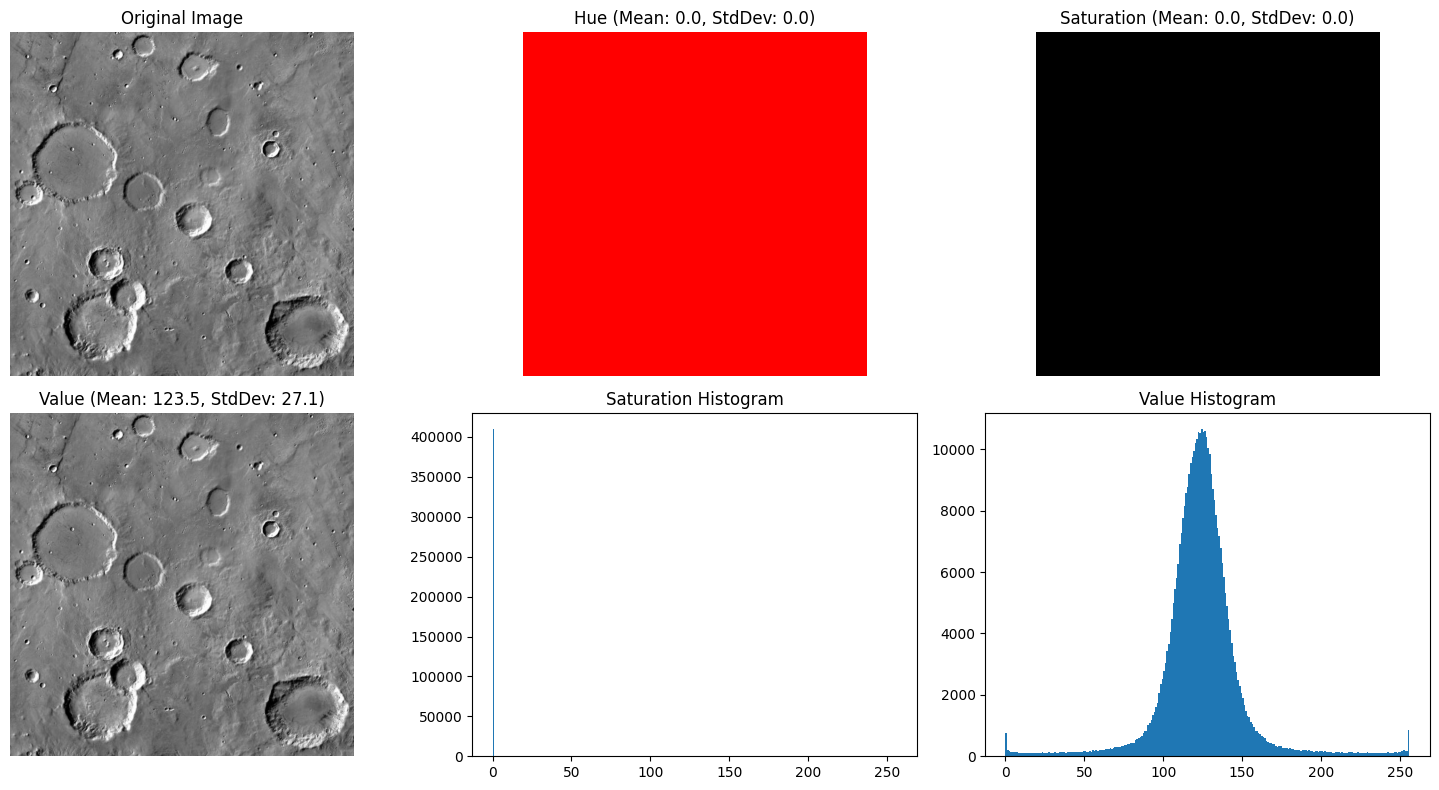

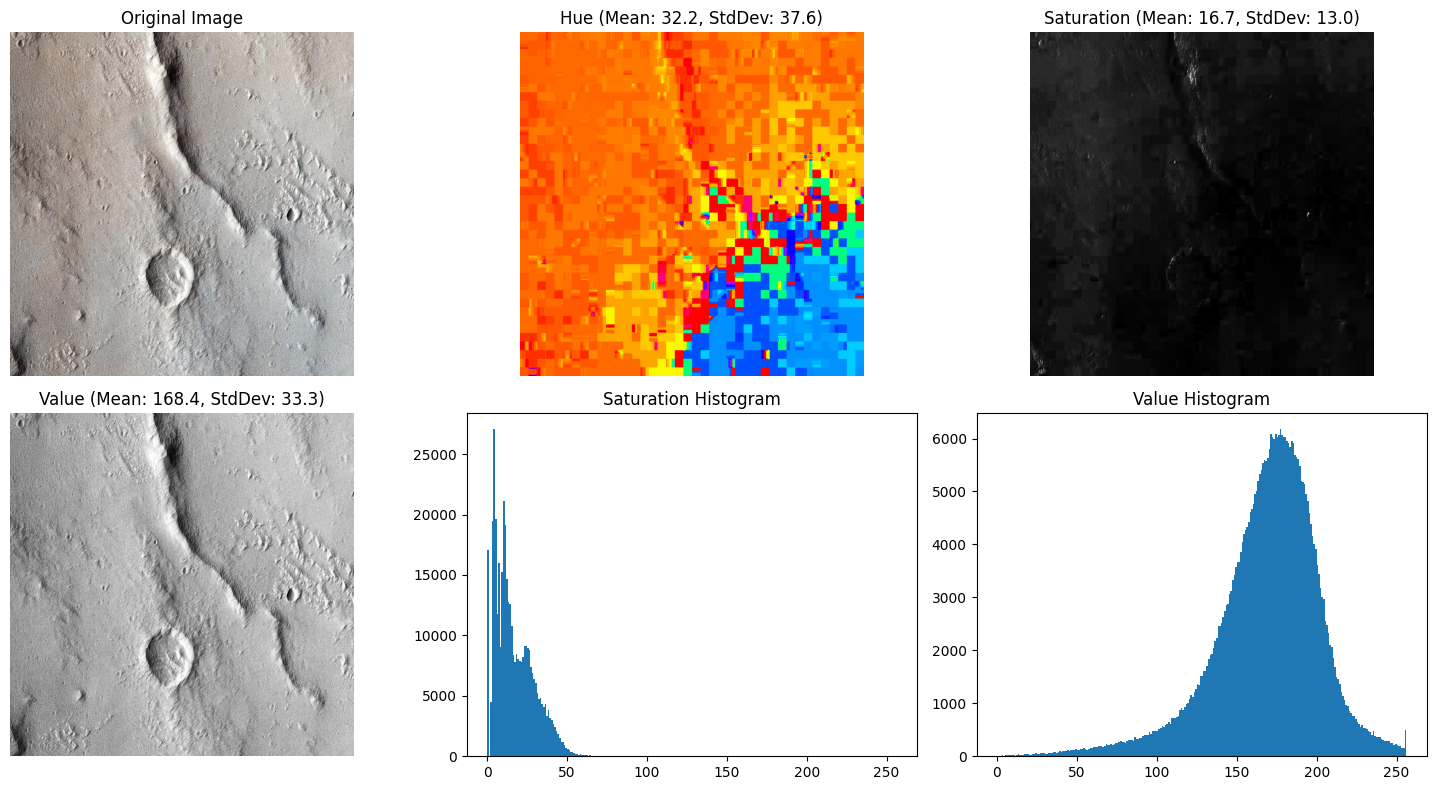

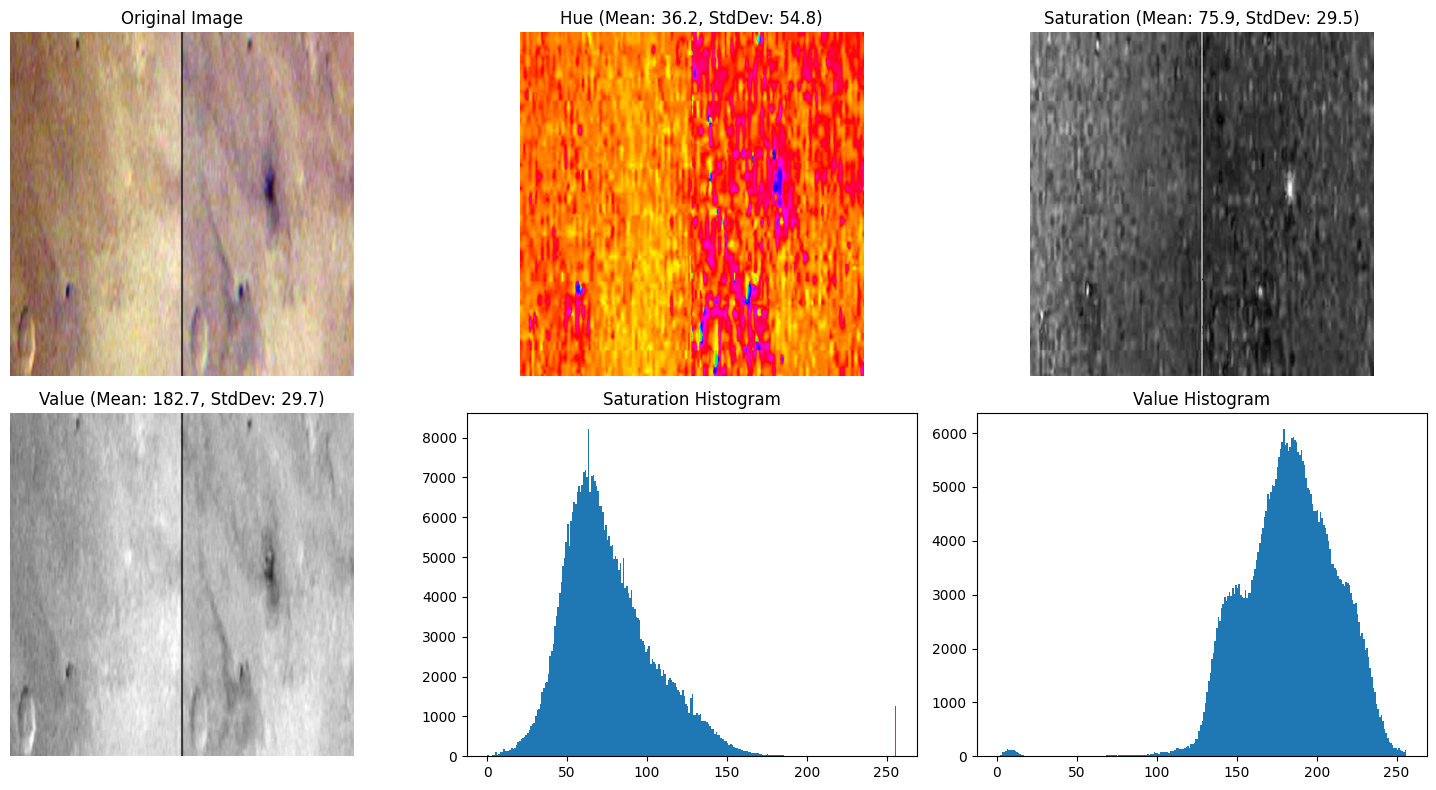

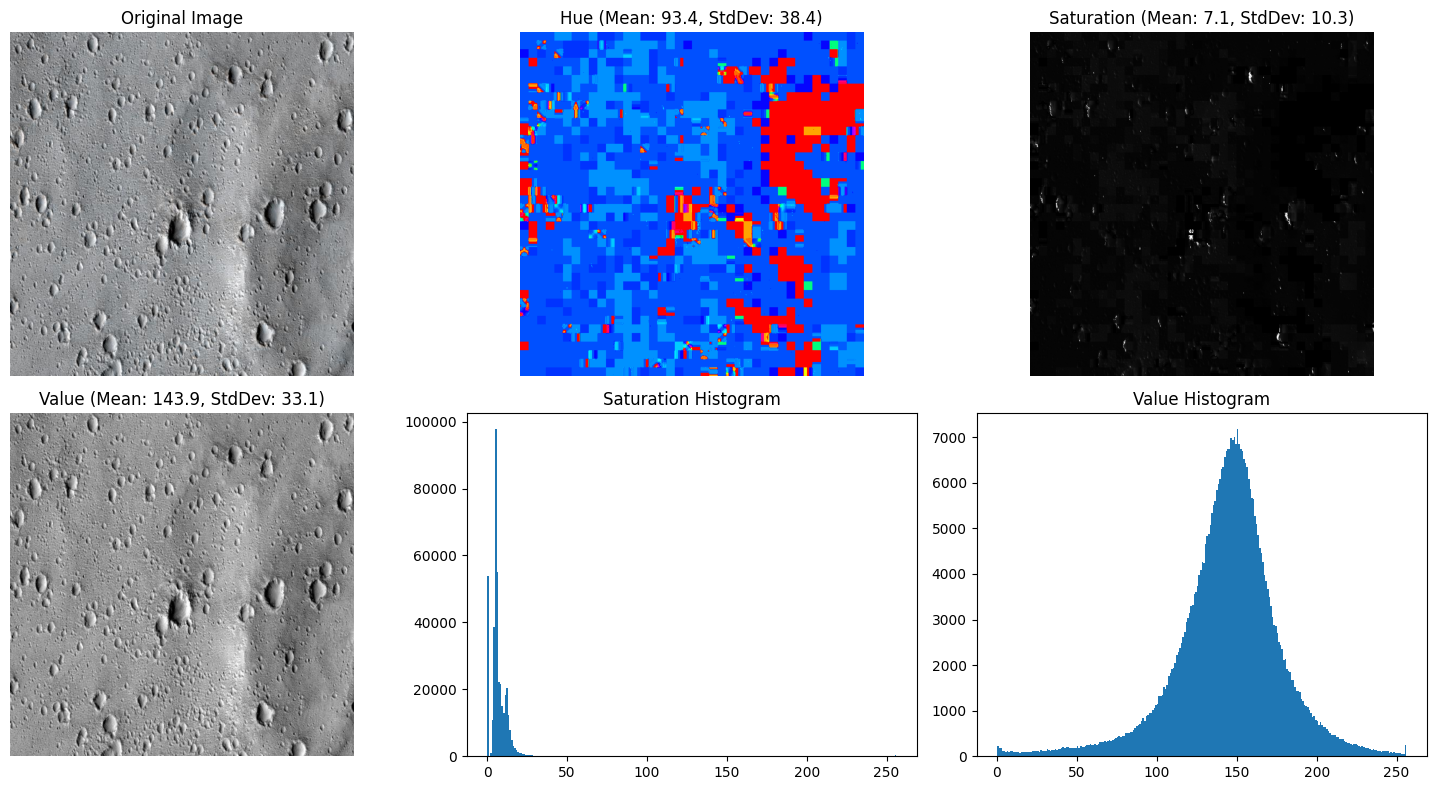

Processing image 11/135: mars_crater--86-_jpg.rf.81699898067809e7560109fb72a56670.jpg
Processing image 21/135: mars_crater--8-_jpg.rf.85af0fa193ad2d5b0087dc48ec7341c6.jpg
Processing image 31/135: mars_crater--17-_jpg.rf.c051d4c804f2fed2aa32999cc9fd0b48.jpg
Processing image 41/135: mars_crater--116-_jpg.rf.2e550a693a8800808e68848484716b95.jpg
Processing image 51/135: mars_crater--110-_jpg.rf.593f6a3d9aed98e7a08955e700765222.jpg
Processing image 61/135: mars_crater--2-_jpg.rf.a65bb7ee68968509ac0b28df75e1f251.jpg
Processing image 71/135: mars_crater--89-_jpg.rf.a57ed45379b066a537e1203ac9827a27.jpg
Processing image 81/135: mars_crater--81-_jpg.rf.147703ba93a36a6a753992752f0a1789.jpg
Processing image 91/135: mars_crater--61-_jpg.rf.1398b749af6c18cf177cc97396129bd0.jpg
Processing image 101/135: mars_crater--104-_jpg.rf.2ff6036b976ac6bbba612dd48f144d4d.jpg
Processing image 111/135: mars_crater--115-_jpg.rf.8b1bf8c37395c894e88e543ccb4cc42f.jpg
Processing image 121/135: 013_png.rf.ee44d5aa33fd3

In [23]:
#################################
#### Classify By Lighting #######
#################################

image_folder = "real_craters"
output_folder = "by_lighting"
df = classify_images_by_hsv(image_folder, visualize_samples=True)

def create_and_clean_category_folders(output_folder, category_groups):
    """
    Create and clean category folders based on provided category groups
    
    Args:
        output_folder: Base folder where category folders will be created
        category_groups: Dictionary mapping category types to lists of categories
    """
    for category_type, categories in category_groups.items():
        for category in categories:
            folder_name = f"{category_type}_{category}"
            category_path = os.path.join(output_folder, folder_name)
            
            # Create folder
            os.makedirs(category_path, exist_ok=True)
            
            # Clean folder
            removed_count = clean_folder(category_path)
            print(f"Cleaned {folder_name}: removed {removed_count} files")

# Define all categories in one place
category_groups = {
    'brightness': ['dark', 'medium', 'bright'],
    'saturation': ['low_sat', 'medium_sat', 'high_sat'],
    'contrast': ['low_contrast', 'medium_contrast', 'high_contrast'],
    'hue': ['red', 'orange', 'yellow_brown', 'other']
}

# Create and clean all category folders with one function call
create_and_clean_category_folders(output_folder, category_groups)

# Copy images to their respective brightness category folders
for _, row in df.iterrows():
    if pd.notna(row['brightness']):
        source = os.path.join(image_folder, row['filename'])
        dest = os.path.join(output_folder, "brightness_" + row['brightness'], row['filename'])
        shutil.copy2(source, dest)
        
    if pd.notna(row['saturation']):
        source = os.path.join(image_folder, row['filename'])
        dest = os.path.join(output_folder, "saturation_" + row['saturation'], row['filename'])
        shutil.copy2(source, dest)
        
    if pd.notna(row['contrast']):
        source = os.path.join(image_folder, row['filename'])
        dest = os.path.join(output_folder, "contrast_" + row['contrast'], row['filename'])
        shutil.copy2(source, dest)
    
    if pd.notna(row['hue_category']):
        source = os.path.join(image_folder, row['filename'])
        dest = os.path.join(output_folder, "hue_" + row['hue_category'], row['filename'])
        shutil.copy2(source, dest)

In [ ]:
def get_size_from_folder_structure(filename):
    """Get the size category based on which subfolder contains the image"""
    for size in ['small', 'medium', 'big', 'massive']:
        size_path = os.path.join('by_size', size, filename)
        if os.path.exists(size_path):
            return size
    
    # If not found in any size folder, check the main folder
    if os.path.exists(os.path.join('real_craters', filename)):
        return 'uncategorized'
    
    return 'unknown'

# After running your HSV analysis which creates 'df'
# Add the size information from your folder structure
df['size_category'] = df['filename'].apply(get_size_from_folder_structure)

In [26]:
# Create multi-category labels for each image
df['combined_category'] = df.apply(
    lambda row: f"{row['size_category']}_{row['contrast']}_{row['brightness']}_{row['hue_category']}_{row['saturation']}",
    axis=1
)

# Count images in each combined category
category_counts = df['combined_category'].value_counts()

# Sample from each category (adjust sample size based on count)
reference_images = []
for category, count in category_counts.items():
    if count > 0:
        # Sample min(count, 2) images from this category
        sample_size = min(count, 2)
        category_df = df[df['combined_category'] == category]
        sampled = category_df.sample(sample_size)
        reference_images.extend(sampled['filename'].tolist())

print(len(reference_images))
# If you haven't reached 50 images, add more from underrepresented categories
# if len(reference_images) < 50:
    # Add logic to select more images from underrepresented dimensions

68


In [27]:
import os
import shutil

# Create a reference images folder
reference_folder = "reference_images"
os.makedirs(reference_folder, exist_ok=True)

# Clean the folder if it already exists
removed_count = clean_folder(reference_folder)
print(f"Cleaned {reference_folder}: removed {removed_count} files")

# Copy the selected reference images to the folder
for filename in reference_images:
    # Find the source file - check in each of your folders
    source_file = None
    
    # Check in main folder
    if os.path.exists(os.path.join("real_craters", filename)):
        source_file = os.path.join("real_craters", filename)
    
    # Check in size folders
    if not source_file:
        for size in ['small', 'medium', 'big', 'massive']:
            size_path = os.path.join("by_size", size, filename)
            if os.path.exists(size_path):
                source_file = size_path
                break
    
    # If source file found, copy it
    if source_file:
        dest_file = os.path.join(reference_folder, filename)
        shutil.copy2(source_file, dest_file)
        print(f"Copied {filename} to reference folder")
    else:
        print(f"Warning: Could not find source file for {filename}")

print(f"Copied {len(os.listdir(reference_folder))} reference images to {reference_folder}")

Cleaned reference_images: removed 0 files
Copied mars_crater--23-_jpg.rf.ab2b0f47006c0c17260c312215dcfb88.jpg to reference folder
Copied mars_crater--102-_jpg.rf.9cdbcc724e2e7baf5c5c17aed91c769b.jpg to reference folder
Copied 016_png.rf.1973f9540ae7f672257609a8e5721ab3.jpg to reference folder
Copied 017_png.rf.1504c0d3ecbf20af6bc5114ca197a0dd.jpg to reference folder
Copied mars_crater--40-_jpg.rf.29e123c14a95b2e0fcdc93e9e8cff902.jpg to reference folder
Copied mars_crater--77-_jpg.rf.64732a16676a6c3222f67571cf1d6618.jpg to reference folder
Copied mars_crater--75-_jpg.rf.210df1cf8ebc1b962b63621720ecf926.jpg to reference folder
Copied mars_crater--113-_jpg.rf.a7713d55de03a1a7487429d414e1005c.jpg to reference folder
Copied mars_crater--31-_jpg.rf.5030dfd316db1570d5f2ad396fa87d4d.jpg to reference folder
Copied mars_crater--91-_jpg.rf.9203caee622cf671580b91536e36e7e2.jpg to reference folder
Copied mars_crater--16-_jpg.rf.bf5f6796b4ec5d351b47efae2e866934.jpg to reference folder
Copied mars_cr